### Hotspot Map

#### Importing Packages and Loading Data

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import joblib
from pathlib import Path

project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
wards_path = project_root / "data" / "raw" / "Wards_May_2024_Boundaries_UK_BGC.geojson"
maps_dir = project_root / "reports"/ "figures"

In [6]:
model = joblib.load(models_dir / "best_model.joblib")
df = pd.read_parquet(processed_dir / "model_features.parquet")
df["month_date"] = pd.to_datetime(df["month_date"])
wards = gpd.read_file(wards_path)

#### Generating Predictions for recent month

In [7]:
# December 2025
target_month = df["month_date"].max()

In [8]:
# Categorical Encoding
df["ward_id"] = df["ward_code"].astype("category").cat.codes
df["type_id"] = df["crime_type"].astype("category").cat.codes


In [9]:
feature_cols = [
    "lag_1", "lag_2", "lag_3", "lag_12", "roll_mean_3",
    "month_num",
    "ward_id", "type_id",
]

month_rows = df[df["month_date"] == target_month].copy()
month_rows["predicted"] = model.predict(month_rows[feature_cols])

In [10]:
# # Sum predicted and actual crimes per ward across all 10 crime types
ward_predictions = (
    month_rows.groupby(["ward_code", "ward_name", "borough"])
    .agg(predicted=("predicted", "sum"),
         actual=("crime_count", "sum"))
    .reset_index()
    .round(1)
)


In [11]:
ward_predictions

,ward_code,ward_name,borough,predicted,actual
0,E05009288,Aldersgate,City of London,12.1,12
1,E05009289,Aldgate,City of London,30.3,24
2,E05009290,Bassishaw,City of London,11.7,13
3,E05009291,Billingsgate,City of London,13.4,27
4,E05009292,Bishopsgate,City of London,123.9,139
...,...,...,...,...,...
698,E05014115,Streatham St Leonard's,Lambeth,174.9,160
699,E05014116,Streatham Wells,Lambeth,63.2,54
700,E05014117,Vauxhall,Lambeth,235.0,215
701,E05014118,Waterloo & South Bank,Lambeth,461.3,546


#### Joining Predictions to Ward Polygons

In [12]:
# Bringing predictions onto the boundary polygons
map_data = wards.merge(
    ward_predictions,
    left_on="WD24CD",
    right_on="ward_code",
    how="inner",
)

#### Building the Map

In [13]:
# Centring the Map on Central London
central_london = [51.5074, -0.1278]

m = folium.Map(location=central_london, zoom_start=11)

m

In [14]:
# Calculating the prediction error column for the tooltip
map_data["error"] = (map_data["predicted"] - map_data["actual"]).round(1)

In [ ]:
# Choropleth colors wards by predicted crime count
folium.Choropleth(
    geo_data=map_data.__geo_interface__,
    data=map_data,
    columns=["WD24CD", "predicted"],
    key_on="feature.properties.WD24CD",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name=f"Predicted crime count, {target_month:%b %Y}",
).add_to(m)

In [19]:
# Transparent overlay carrying the tooltips
folium.GeoJson(
    map_data,
    style_function=lambda x: {"fillOpacity": 0, "color": "transparent"},
    tooltip=folium.GeoJsonTooltip(
        fields=["ward_name", "borough", "predicted", "actual", "error"],
        aliases=["Ward:", "Borough:", "Predicted:", "Actual:", "Error (P vs A):"],
        localize=True, sticky=True,
    ),
).add_to(m)

In [20]:
m

In [21]:
# Saving
out_path = maps_dir / "london_hotspots.html"
m.save(str(out_path))

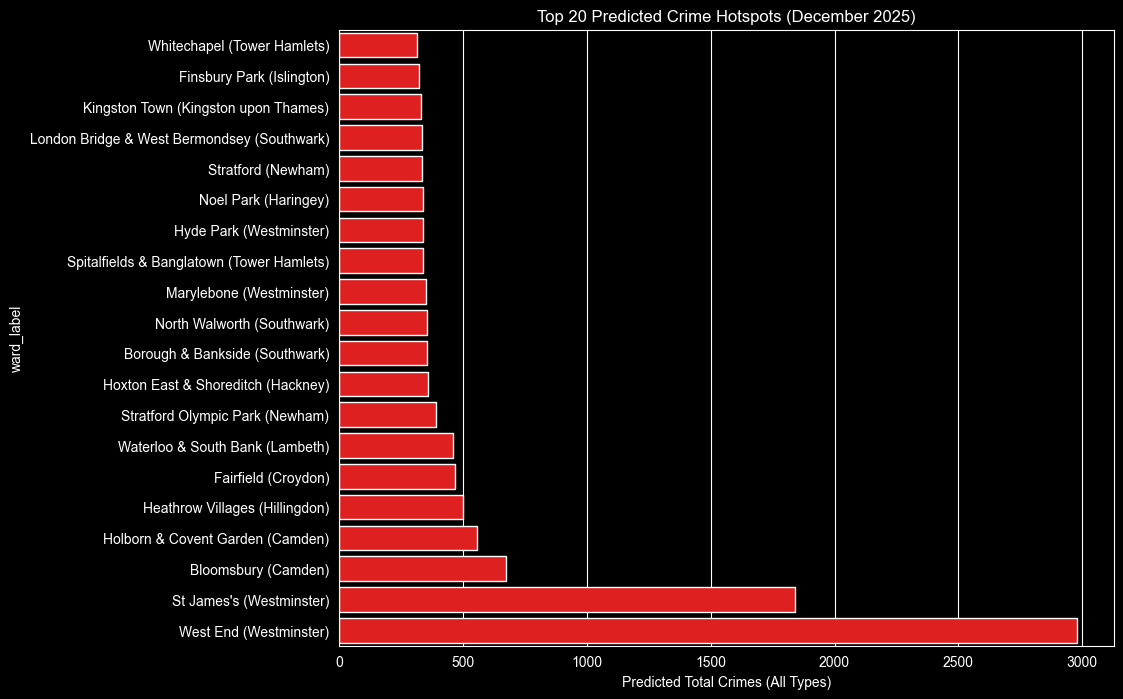

In [22]:
top20 = ward_predictions.sort_values("predicted", ascending=False).head(20)
top20["ward_label"] = top20["ward_name"] + " (" + top20["borough"] + ")"

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=top20.sort_values("predicted"),
    x="predicted", y="ward_label",
    color="red", ax=ax,
)
ax.set_title(f"Top 20 Predicted Crime Hotspots (December 2025)")
ax.set_xlabel("Predicted Total Crimes (All Types)")
;

figures_dir = project_root / "reports" / "figures"
fig.savefig(figures_dir / "08_top_hotspots.png", bbox_inches="tight")